# Предсказание того, является ли аккаунт Reddit ботом или человеком, на основе статистики коментария и аккаунта

## 1. Загрузка данных

In [1]:
import warnings
warnings.simplefilter('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix,\
     ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve
import shap
import joblib
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('reddit_dead_internet_analysis_2026.csv')
df.head()

,comment_id,subreddit,account_age_days,user_karma,reply_delay_seconds,sentiment_score,avg_word_length,contains_links,is_bot_flag,bot_type_label,bot_probability
0,t1_3148938807,funny,2264,34192,1854,-0.60,4.62,False,False,None (Human),0.093
1,t1_2516748923,gaming,1654,2812,1033,0.15,5.84,False,False,None (Human),0.117
2,t1_833922318,politics,2442,37109,2703,0.35,5.73,False,False,None (Human),0.115
3,t1_3987809057,funny,168,32997,2811,-0.74,4.58,False,False,None (Human),0.094
4,t1_3931039688,gaming,801,25088,1721,-0.96,5.78,False,False,None (Human),0.116


## 2. Посмотрим какие данные у нас в датасете

In [3]:
print("Информация о датасете:")
df.info()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   comment_id           500 non-null    object 
 1   subreddit            500 non-null    object 
 2   account_age_days     500 non-null    int64  
 3   user_karma           500 non-null    int64  
 4   reply_delay_seconds  500 non-null    int64  
 5   sentiment_score      500 non-null    float64
 6   avg_word_length      500 non-null    float64
 7   contains_links       500 non-null    bool   
 8   is_bot_flag          500 non-null    bool   
 9   bot_type_label       500 non-null    object 
 10  bot_probability      500 non-null    float64
dtypes: bool(2), float64(3), int64(3), object(3)
memory usage: 36.3+ KB


In [4]:
print("Распределение целевой переменной (is_bot_flag):")
print(df['is_bot_flag'].value_counts())

Распределение целевой переменной (is_bot_flag):
is_bot_flag
False    282
True     218
Name: count, dtype: int64


In [5]:
print("Пропущенные значения:")
print(df.isnull().sum())

Пропущенные значения:
comment_id             0
subreddit              0
account_age_days       0
user_karma             0
reply_delay_seconds    0
sentiment_score        0
avg_word_length        0
contains_links         0
is_bot_flag            0
bot_type_label         0
bot_probability        0
dtype: int64


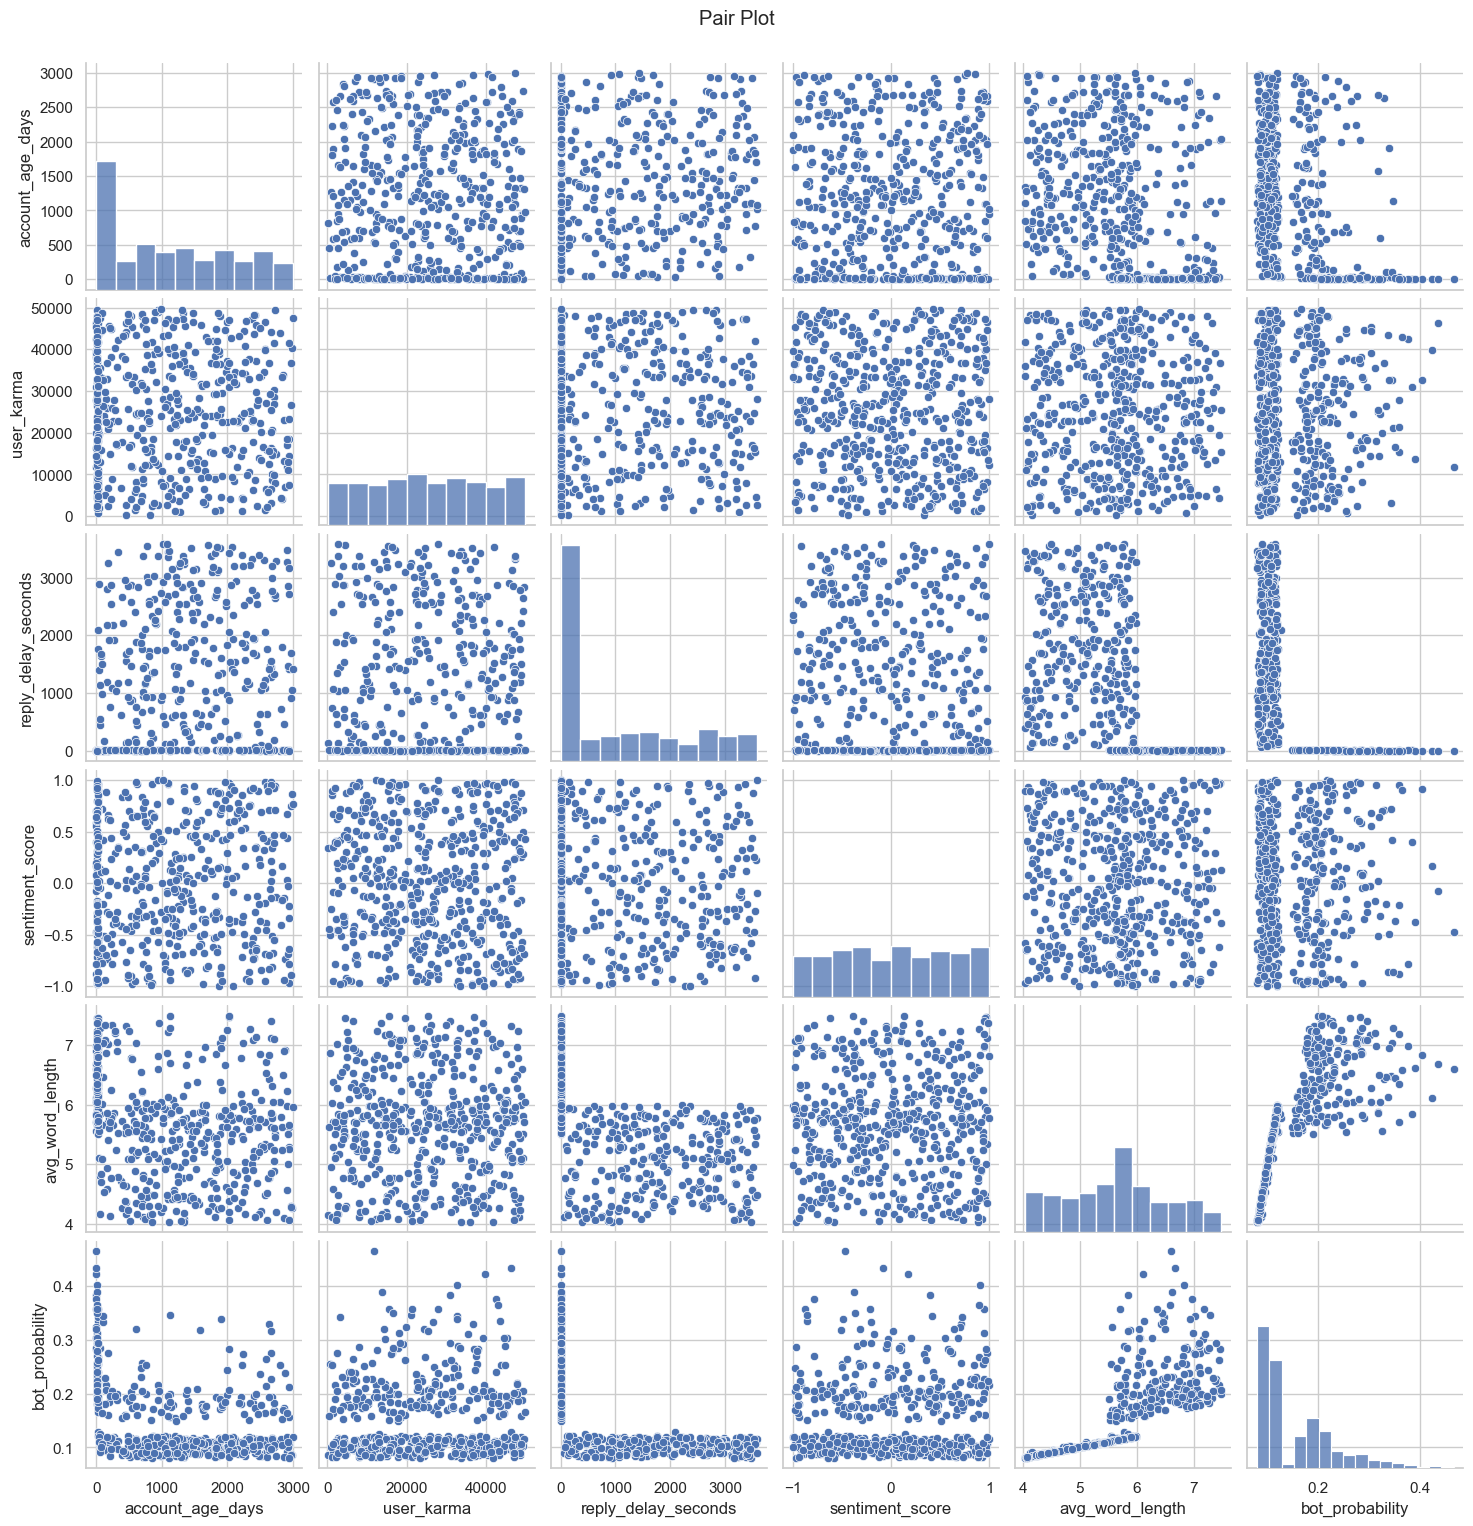

In [6]:
# Распределения числовых признаков
num_df = df.select_dtypes(include=[np.number])
sns.pairplot(num_df)
plt.suptitle('Pair Plot', y=1.02)
plt.show()

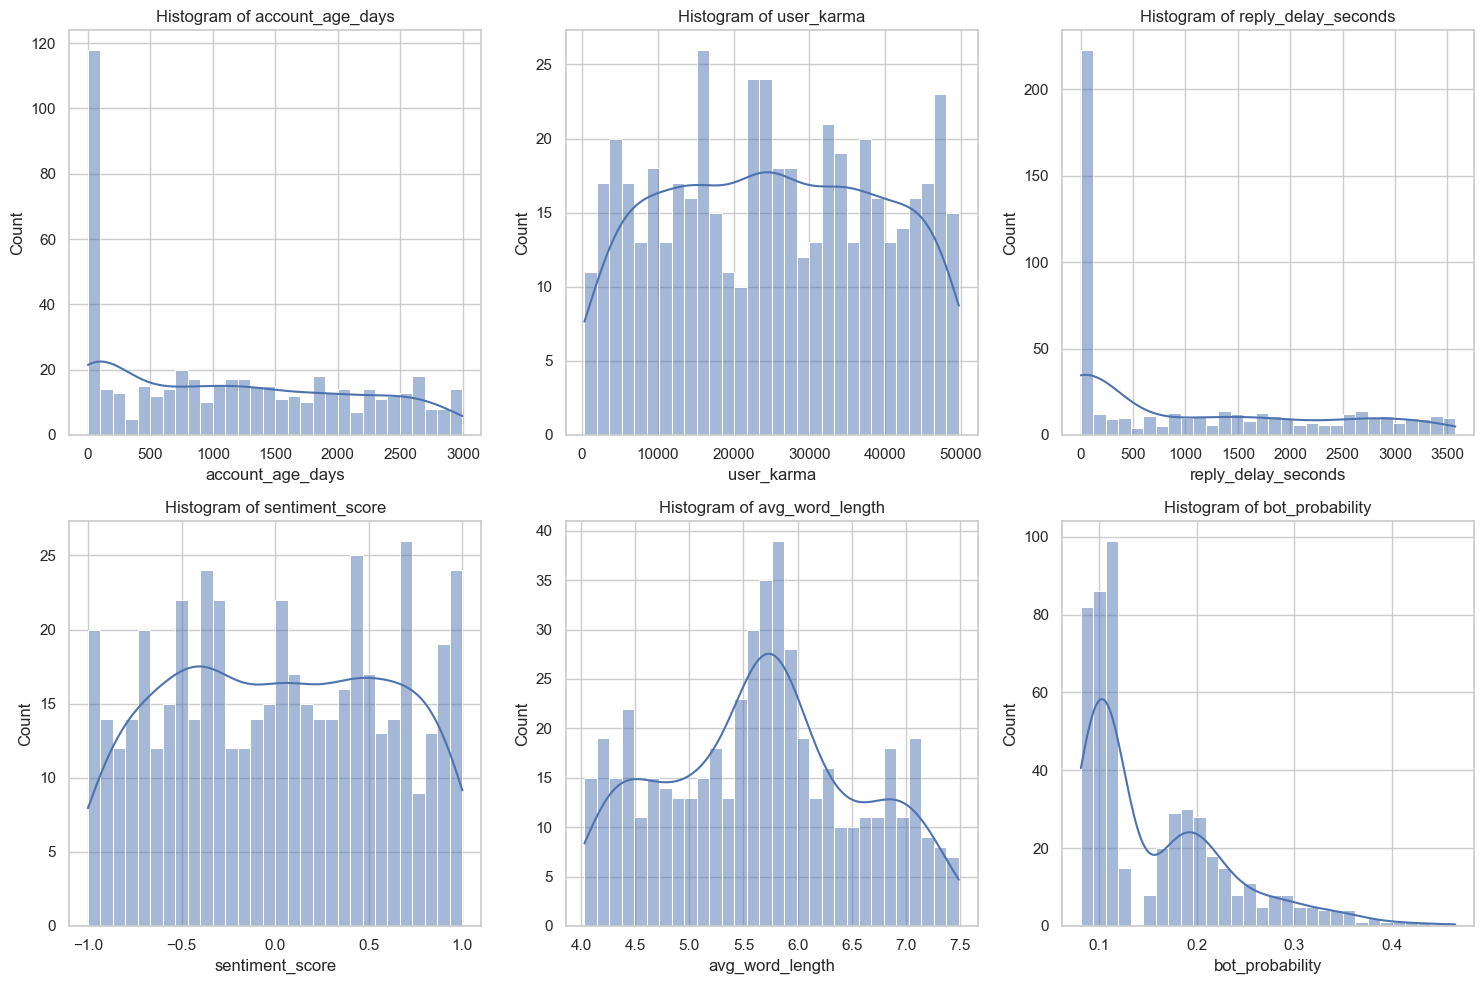

In [7]:
#KDE
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_df):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

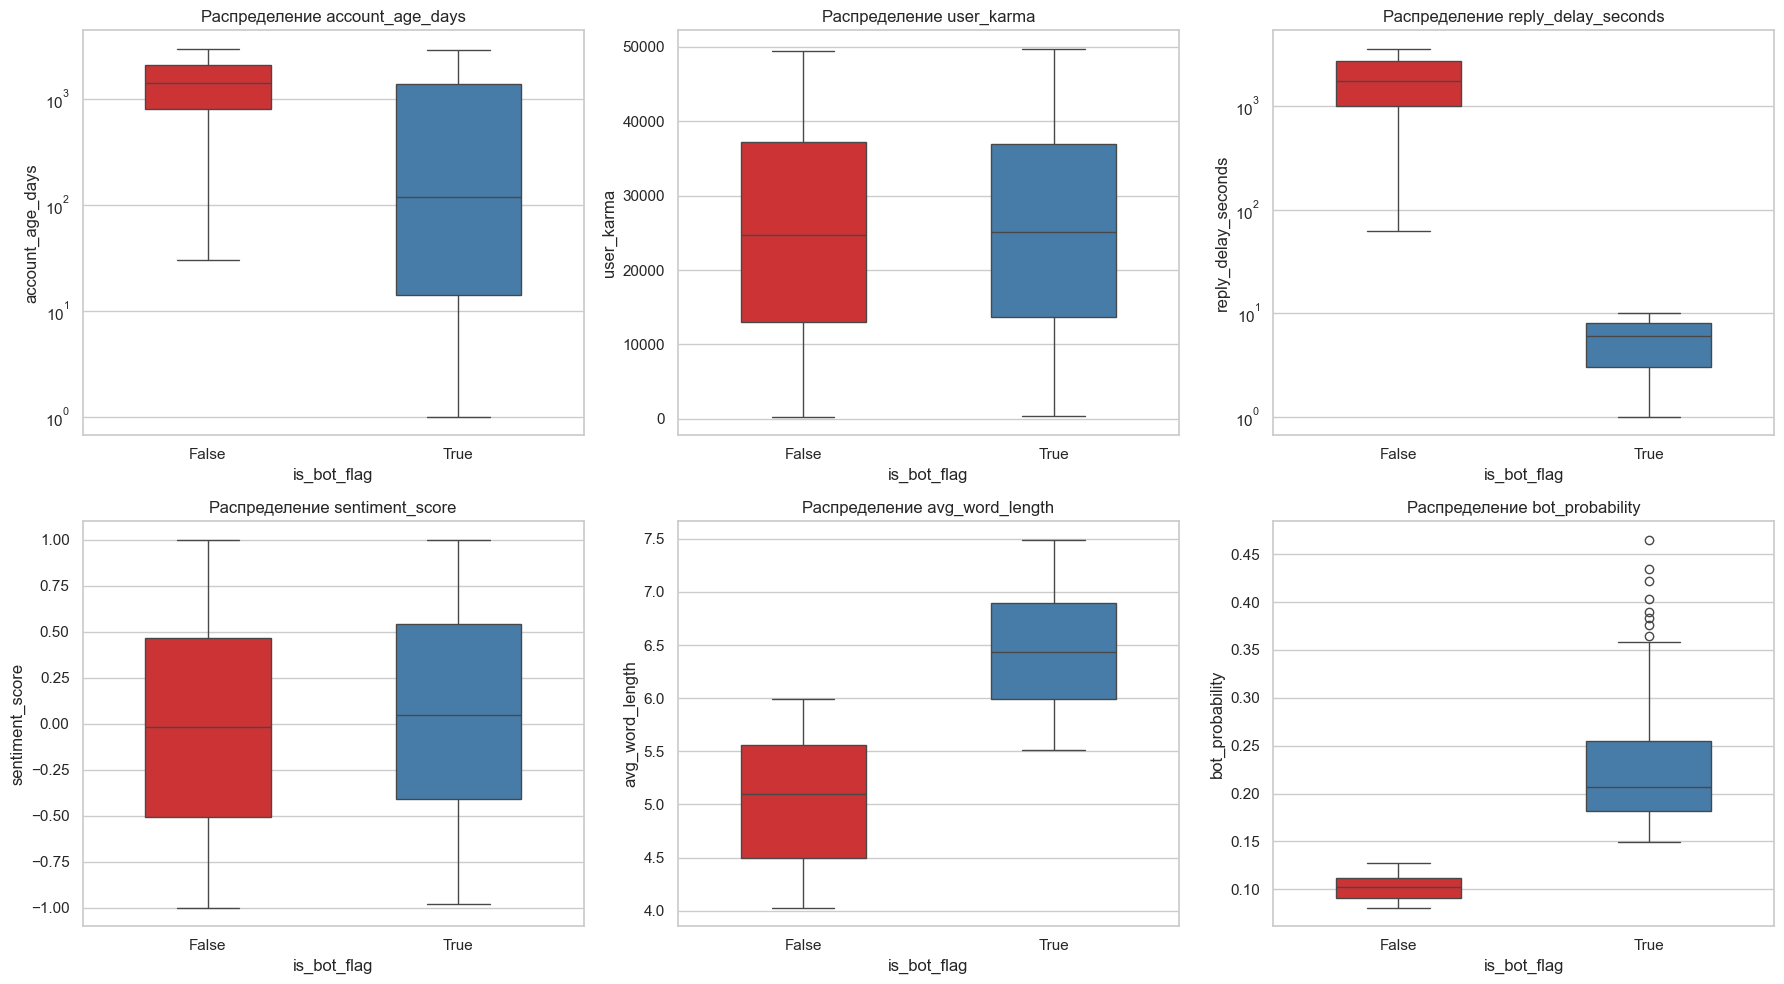

In [8]:
#Boxplot
fig, axes = plt.subplots(2, 3, figsize=(18, 5 * 2))
axes = axes.flatten()
for i, col in enumerate(num_df):
    ax = axes[i]
    sns.boxplot(data=df, x='is_bot_flag', y=col, ax=ax, hue='is_bot_flag', palette='Set1', legend=False, width=0.5)
    ax.set_title(f'Распределение {col}', fontsize=12)
    if df[col].max() / (df[col].min() + 1e-9) > 1000:
        ax.set_yscale('log')
plt.tight_layout()
plt.show()

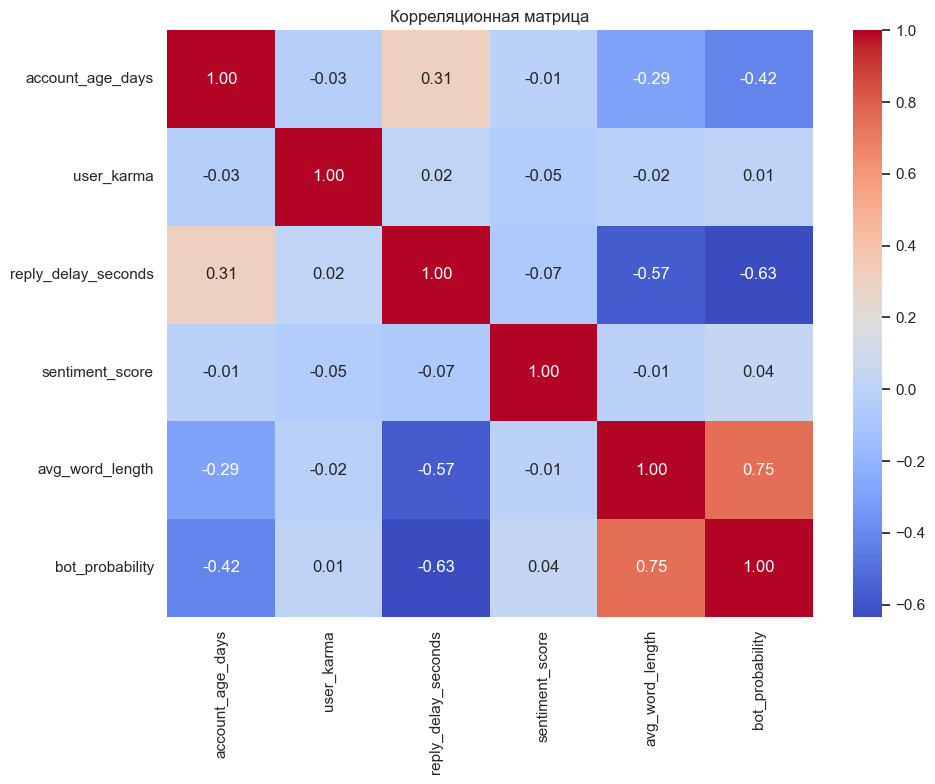

In [9]:
# Корреляционная матрица (только числовые + целевая)
plt.figure(figsize=(10, 8))
corr_matrix = num_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

## 3. Предобработка данных


In [10]:
def preprocess_data(df):
  """Генерация фичей, очистка данных, кодирование и сплит."""
  df_proc = df.copy()

  # Удаление ликов и лишних колонок
  X = df_proc.drop(['comment_id', 'is_bot_flag', 'bot_type_label', 'bot_probability'], axis=1, errors='ignore')
  y = df_proc['is_bot_flag'].astype(int)

  # Сплит
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0, stratify=y)

  # OHE для категориальных фичей
  cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
  X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
  X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
  X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

  # Скейлинг
  scaler = StandardScaler()
  X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=X_train_encoded.columns)
  X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=X_test_encoded.columns)

  return X_train_encoded, X_test_encoded, y_train, y_test, X_train_scaled, X_test_scaled

In [11]:
def train_model(model, X_train, y_train):
  """Обучение модели."""
  model.fit(X_train, y_train)
  return model

In [12]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model", cv=5):
  """Оценка модели: Кросс-валидация (ROC-AUC) и предсказание на тесте."""
  # Кросс-валидация
  cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')

  # Предсказания
  y_pred = model.predict(X_test)
  y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

  # Метрики
  roc_auc = roc_auc_score(y_test, y_proba)
  f1 = f1_score(y_test, y_pred)

  print(f"--- {model_name} ---")
  print(f"CV ROC-AUC (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
  print(f"Test ROC-AUC: {roc_auc:.4f}")
  print(f"Test F1-Score: {f1:.4f}")
  print("Classification Report:\n", classification_report(y_test, y_pred))
  print("-" * 40 + "\n")

  return {'cv_roc_auc': cv_scores.mean(), 'test_roc_auc': roc_auc, 'test_f1': f1}

## 4. Обучение и оценка моделей

In [13]:
# 1. Препроцессинг
X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled = preprocess_data(df)

In [14]:
# 2. Инициализация моделей
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
}

In [15]:
# 3. Обучение и Оценка
results = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        trained_model = train_model(model, X_train_scaled, y_train)
        res = evaluate_model(trained_model, X_train_scaled, y_train, X_test_scaled, y_test, model_name=name)
    else:
        trained_model = train_model(model, X_train, y_train)
        res = evaluate_model(trained_model, X_train, y_train, X_test, y_test, model_name=name)

    results[name] = res

--- Logistic Regression ---
CV ROC-AUC (mean ± std): 0.9964 ± 0.0044
Test ROC-AUC: 0.9988
Test F1-Score: 0.9862
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       141
           1       0.99      0.98      0.99       109

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250

----------------------------------------

--- Random Forest ---
CV ROC-AUC (mean ± std): 1.0000 ± 0.0000
Test ROC-AUC: 1.0000
Test F1-Score: 1.0000
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       141
           1       1.00      1.00      1.00       109

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

--------------------------------------

In [16]:
# Финальное сравнение моделей и выбор лучшей
best_model_name = max(results, key=lambda k: results[k]['cv_roc_auc'])
best_cv_score = results[best_model_name]['cv_roc_auc']

print(f"Лучшая модель: {best_model_name} (CV ROC-AUC: {best_cv_score:.4f})")

Лучшая модель: Random Forest (CV ROC-AUC: 1.0000)


## 5. Оценка качества и интерпретация модели

In [17]:
# Извлекаем лучшую модель из словаря
best_model = models[best_model_name]
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

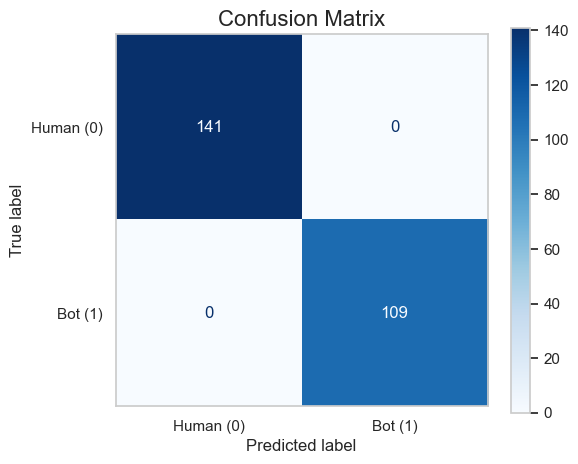

In [18]:
# Confusion Matrix (Матрица ошибок)
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human (0)', 'Bot (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Confusion Matrix', fontsize=16)
plt.grid(False)
plt.show()

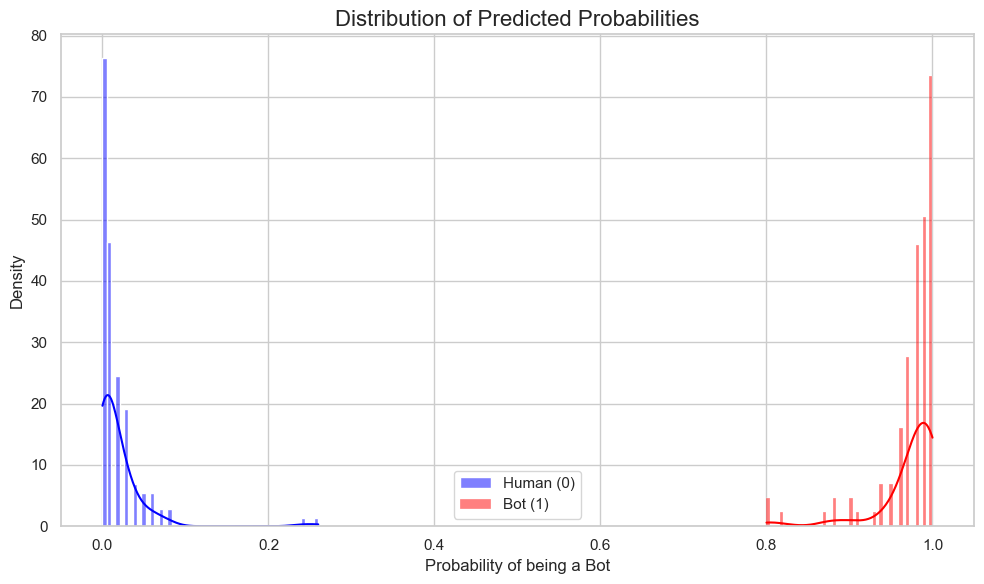

In [19]:
# Распределение предсказанных вероятностей
plt.figure(figsize=(10, 6))
sns.histplot(y_prob[y_test == 0], bins=50, color='blue', alpha=0.5, label='Human (0)', kde=True, stat="density")
sns.histplot(y_prob[y_test == 1], bins=50, color='red', alpha=0.5, label='Bot (1)', kde=True, stat="density")

plt.title('Distribution of Predicted Probabilities', fontsize=16)
plt.xlabel('Probability of being a Bot')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

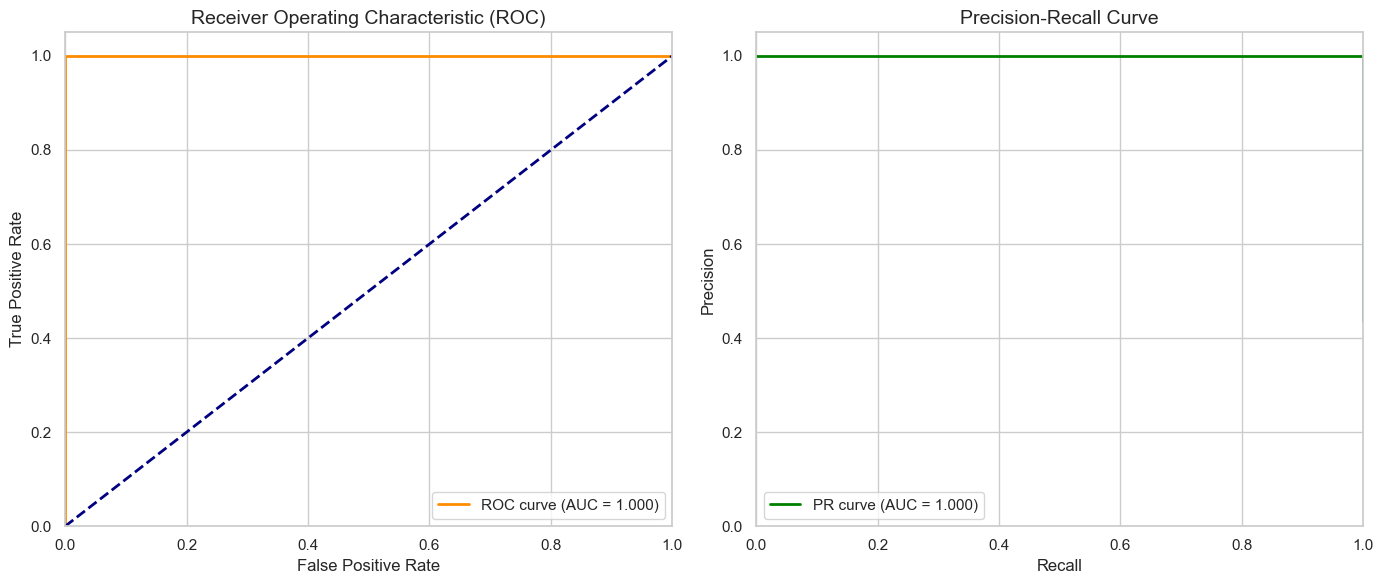

In [20]:
# ROC-Кривая и PR-Кривая
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=14)
axes[0].legend(loc="lower right")

# PR Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
axes[1].plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=14)
axes[1].legend(loc="lower left")
plt.tight_layout()
plt.show()

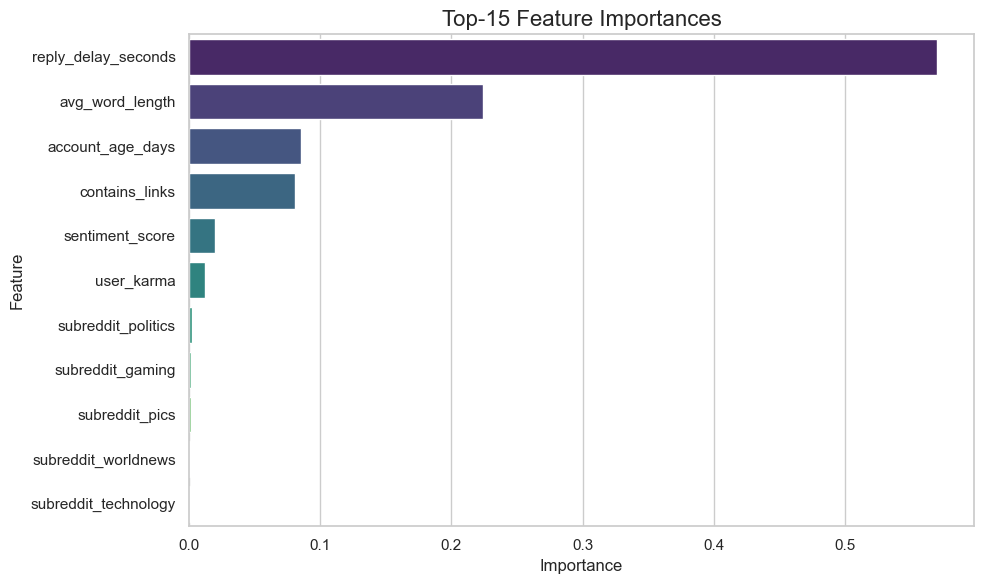

In [21]:
# Feature Importance (Важность признаков)
# Проверяем, поддерживает ли модель атрибут feature_importances_
model_to_inspect = best_model

if hasattr(model_to_inspect, 'feature_importances_'):
    importances = model_to_inspect.feature_importances_
    features = X_train.columns

    indices = np.argsort(importances)[::-1][:15]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette="viridis")
    plt.title('Top-15 Feature Importances', fontsize=16)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("Модель не поддерживает стандартный вывод feature_importances_.")

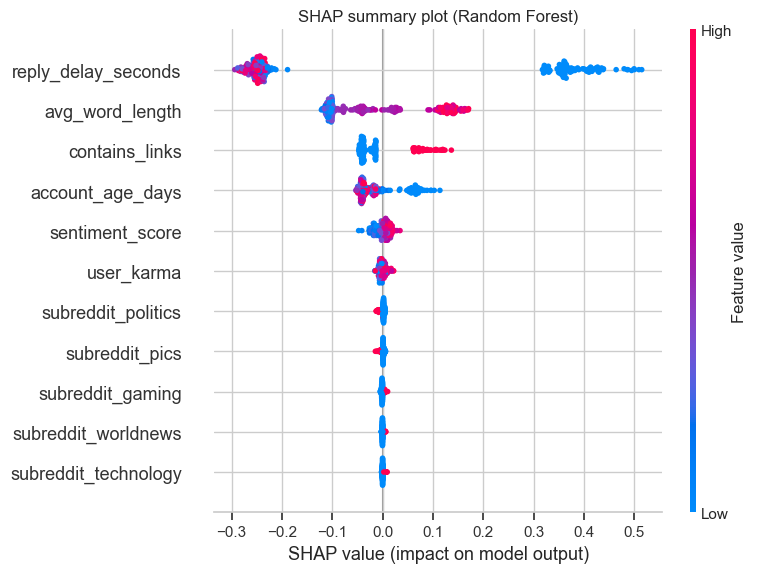

In [22]:
# SHAP
if best_model_name == 'Logistic Regression':
    print("Лучшая модель — Logistic Regression.")
else:
    shap_model = best_model
    shap_data = X_train

    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(shap_data)
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1] 
    elif len(shap_values.shape) == 3:
        shap_values_to_plot = shap_values[:, :, 1]
    else:
        shap_values_to_plot = shap_values

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_to_plot, shap_data, plot_type="dot", show=False)
    plt.title(f"SHAP summary plot ({best_model_name if best_model_name != 'Logistic Regression' else 'CatBoost'})")
    plt.tight_layout()
    plt.show()

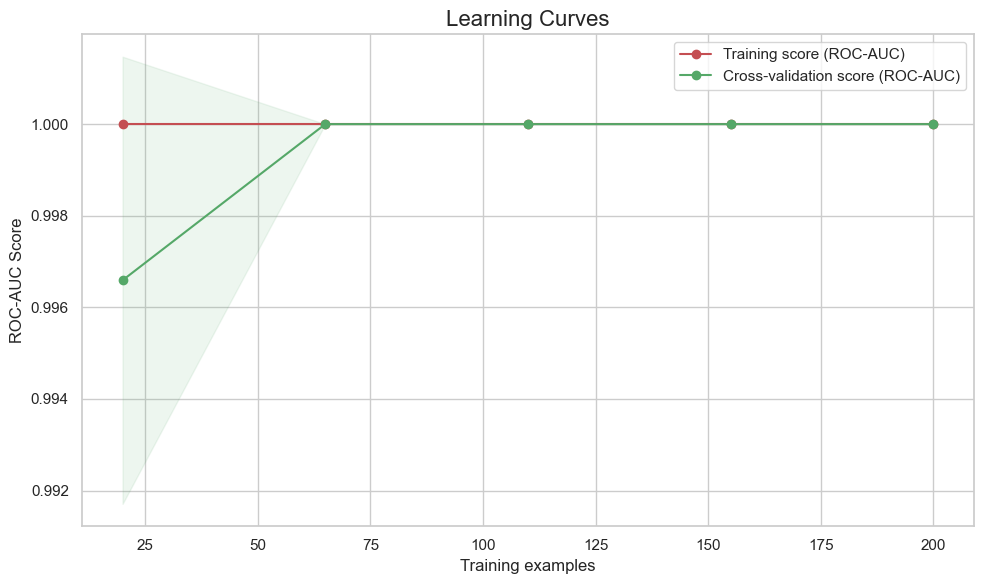

In [23]:
# Learning Curves (Кривые обучения)
plt.figure(figsize=(10, 6))
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='roc_auc'
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score (ROC-AUC)")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score (ROC-AUC)")

plt.title('Learning Curves', fontsize=16)
plt.xlabel('Training examples')
plt.ylabel('ROC-AUC Score')
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## 6. Сохранение модели

In [24]:
model_filename = "model.pkl"
joblib.dump(best_model, model_filename)

print(f" Модель успешно сохранена в файл '{model_filename}'")

 Модель успешно сохранена в файл 'model.pkl'
